In [1]:
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt

<img src="github_material.png" width="900">

# Tutorial: Higher-order interactions in healthy ageing

## Objective
In this tutorial, we will analyze redundant and synergistic interactions (using O-Information [1]) across healthy lifespan.
We will use results that have already been computed with the HOI toolbox [2].

<img src="lifespan.png" width="400">

## Definition

The O-information is a multivariate measure of information capable of disentangling whether a subset of a variable `X` is dominated by redundancy or synergy. The O-information is defined as the difference between the Total Correlation and the Dual Total Correlation [1]. As both quantities are respectively linked to redundancy and synergy, the O-information is going to be positive when a system is dominated by redundant interactions and negative when the system is dominated by synergistic interactions. The mathematical definition of the O-information is given by:

$$
\Omega(X^{n})  =  TC(X^{n}) - DTC(X^{n}) \\
               =  (n - 2)H(X^{n}) + \sum_{j=1}^{n} \left[ H(X_{j}) - H(X_{-j}^{n}) \right]
$$

###  Dataset 

The code to compute the metrics used in this tutorial has been made publicly available at www.github.com/brincolab/High-Order-interactions [3]


#### References

[1] Rosas FE, Mediano PAM, Gastpar M, Jensen HJ. Quantifying high-order interdependencies via multivariate extensions of the mutual information. Phys Rev E. 2019 Sep 13;100(3):032305. doi: 10.1103/PhysRevE.100.032305

[2] https://brainets.github.io/hoi/

[3] Marilyn Gatica, Rodrigo Cofre, Pedro A.M. Mediano, Fernando E. Rosas, Patricio Orio, Ibai Diez, Stephan P. Swinnen, and Jesus M. Cortes. 
High-Order Interdependencies in the Aging Brain. Brain Connectivity, 2021, doi: 10.1089/brain.2020.0982

## 1. Computing redundancy and synergy for triplets
This part is optional. In this tutorial, we will load the results generated from this line of code, but you may run the block below to compute redundancy and synergy for triplets using the HOI package (https://brainets.github.io/hoi/).

In [2]:
# import hoi # Install dependencies and packages: https://brainets.github.io/hoi/
# from collections import OrderedDict
# from itertools import combinations
# import os


# # Initialize ordered dictionaries to store results
# Oinfo = OrderedDict()
# Red = OrderedDict()
# Syn = OrderedDict()

# num_subj = 161
# nodes = 20
# ## HOI variables/parameters
# order = 3 #triplets
# nplets = np.array(list(combinations(np.arange(nodes), order)))

# # For each node, find the indices of triplets where the node is involved
# node_to_triplet_indices = []
# for node in range(nodes):
#     indices = np.where(np.any(nplets == node, axis=1))[0]
#     node_to_triplet_indices.append(indices)

# # to save the results
# outdir = "hoi_triplets"
# os.makedirs(outdir, exist_ok=True)

# # Loop over all patients
# for patient in range(1,num_subj+1):
#     if patient % 20 == 0:
#         print(patient)

#     fname = f"./timeseries/ts_m20_p{patient:03d}.txt"
#     dataPatient = np.loadtxt(fname).T # shape: (T, nodes)

#     # Compute O-Information for triplets
#     model = hoi.metrics.Oinfo(dataPatient)
#     result = model.fit(minsize=order, maxsize=order)  # order = 3 for triplets only
#     #Oinfo[patient] = result  # result is a list of Oinfo values for all triplets

#     oinfo_values = np.array(result)  # shape: (num_triplets,)

#     # Separate positive (redundancy) and negative (synergy) contributions
#     red_vals = np.where(oinfo_values > 0, oinfo_values, 0)
#     syn_vals = np.where(oinfo_values < 0, np.abs(oinfo_values), 0)

#     red_nodal = []
#     syn_nodal = []

#     # For each node, average values to node level
#     for indices in node_to_triplet_indices:
#         red_nodal.append(np.mean(red_vals[indices]))
#         syn_nodal.append(np.mean(syn_vals[indices]))

#     # Store results per patient
#     Red[patient] = red_nodal
#     Syn[patient] = syn_nodal
#     break
        
#     fname_red = f"{outdir}/red_m20_p{patient:03d}.npy"
#     fname_syn = f"{outdir}/syn_m20_p{patient:03d}.npy"
    
#     np.save(fname_red, np.asarray(red_nodal))
#     np.save(fname_syn, np.asarray(syn_nodal))


## 2. Load and analyze redundancy and synergy for triplets

### 2.1 Comparison between the youngest and oldest populations

In [3]:
num_subj = 161
nodes = 20

outdir = "hoi_triplets"

# Redundancy and Synergy arrays: sujetos × nodos
Red = np.zeros((num_subj, nodes))
Syn = np.zeros((num_subj, nodes))

for patient in range(1, num_subj + 1):
    fname_red = f"{outdir}/red_m20_p{patient:03d}.npy"
    fname_syn = f"{outdir}/syn_m20_p{patient:03d}.npy"

    Red[patient - 1] = np.load(fname_red)
    Syn[patient - 1] = np.load(fname_syn)

In [4]:
print(np.shape(Red))

(161, 20)


#### Loading the age information

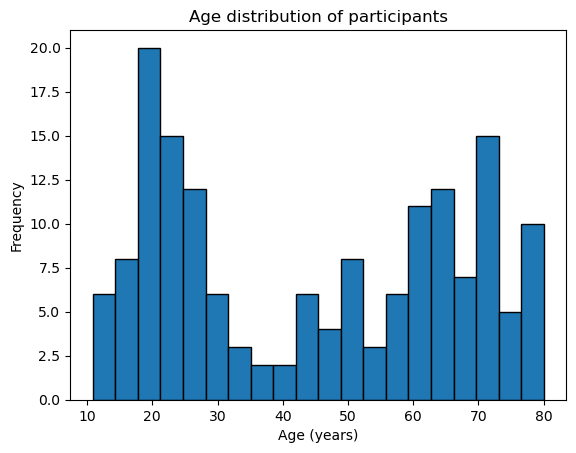

In [5]:
age_data = loadmat("ages_up.mat")["ages_up"]
age_data = age_data.squeeze()                 # (161,)
plt.hist(age_data, bins=20, edgecolor='black')
plt.xlabel('Age (years)')
plt.ylabel('Frequency')
plt.title('Age distribution of participants')

plt.show()


In [6]:
# define age groups
younger_idx = age_data <= 20
older_idx   = age_data >= 60

## Nodal effect of redundancy and synergy

### Redundancy

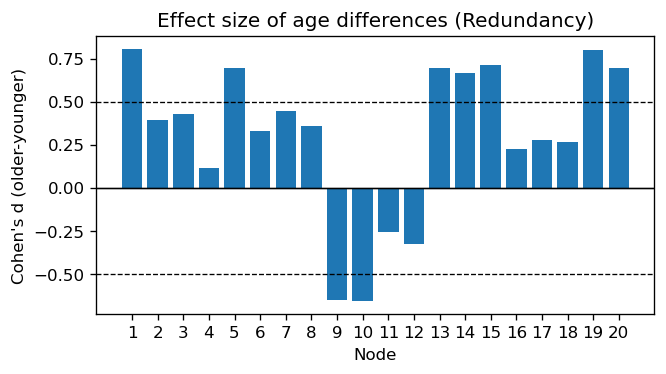

In [7]:
# Cohen's d function
def cohens_d(x, y):
    nx, ny = len(x), len(y)
    vx, vy = np.var(x, ddof=1), np.var(y, ddof=1)
    pooled_std = np.sqrt(((nx - 1)*vx + (ny - 1)*vy) / (nx + ny - 1e-12 - 2))
    return (np.mean(x) - np.mean(y)) / pooled_std

# -------------------------
# Redundancy (Red): (subjects, nodes)
# -------------------------
dvals_red = [cohens_d(Red[older_idx, n],Red[younger_idx, n]) for n in range(nodes)]

plt.figure(figsize=(6, 3), dpi=120)
x = np.arange(1, nodes + 1)
plt.bar(x, dvals_red)
plt.axhline(0, color="k", linewidth=0.8)
plt.xlabel("Node")
plt.xticks(np.arange(1, nodes + 1))
plt.ylabel("Cohen's d (older-younger)")
plt.title("Effect size of age differences (Redundancy)")

plt.axhline(0, color="k", linewidth=0.8)
plt.axhline(0.5, color="k", linestyle="--", linewidth=0.8)
plt.axhline(-0.5, color="k", linestyle="--", linewidth=0.8)

plt.show()

### Synergy

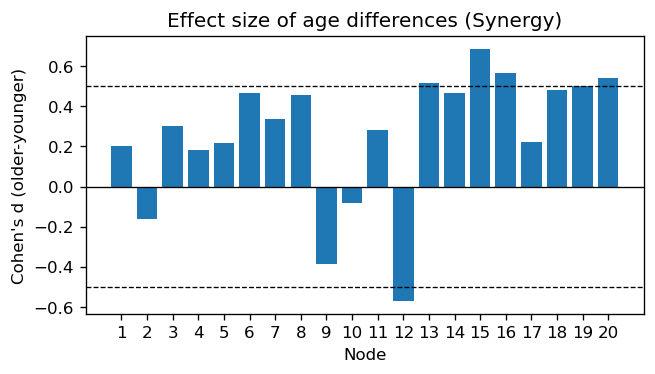

In [8]:

# -------------------------
# Synergy (Syn): (subjects, nodes)
# -------------------------
dvals_syn = [cohens_d(Syn[older_idx, n],Syn[younger_idx, n]) for n in range(nodes)]

plt.figure(figsize=(6, 3), dpi=120)
x = np.arange(1, nodes + 1)
plt.bar(x, dvals_syn)
plt.axhline(0, color="k", linewidth=0.8)
plt.xlabel("Node")
plt.xticks(np.arange(1, nodes + 1))
plt.ylabel("Cohen's d (older-younger)")
plt.title("Effect size of age differences (Synergy)")

plt.axhline(0.5, color="k", linestyle="--", linewidth=0.8)
plt.axhline(-0.5, color="k", linestyle="--", linewidth=0.8)

plt.show()

<img src="SFMs.png" width="400">

* Brain atlas and image: Diez, I., Bonifazi, P., Escudero, I. et al. A novel brain partition highlights the modular skeleton shared by structure and function. Sci Rep 5, 10532 (2015). https://doi.org/10.1038/srep10532

## 2.2 Redundancy and synergy across lifespan

In [9]:
from scipy.stats import pearsonr
from math import ceil

alpha = 0.05 / 20  # Bonferroni for 20 nodes

def plot_age_vs_metric(age, M, ylabel, title):
    nodes = M.shape[1]

    # 1) compute correlations + select significant nodes
    r = np.zeros(nodes)
    p = np.zeros(nodes)
    for n in range(nodes):
        r[n], p[n] = pearsonr(age, M[:, n])
    sig = np.where(p <= alpha)[0]
    print(f"{ylabel}: significant nodes (Bonferroni):", sig + 1)

    # 2) subplot only significant nodes
    if len(sig) == 0:
        print(f"No nodes survived for {ylabel}.")
        return

    ncols = 4
    nrows = ceil(len(sig) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows), squeeze=False)

    for ax, n in zip(axes.ravel(), sig):
        ax.scatter(age, M[:, n], c="k", s=25, alpha=0.6)
        z = np.polyfit(age, M[:, n], 1)
        ax.plot(age, np.polyval(z, age), "r--", lw=1)
        ax.set_title(f"Node {n+1} (r={r[n]:.2f}, p={p[n]:.3g})", fontsize=9)
        ax.set_xlabel("Age")
        ax.set_ylabel(ylabel)

    for ax in axes.ravel()[len(sig):]:
        ax.axis("off")

    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


Redundancy: significant nodes (Bonferroni): [ 1  5  9 10 13 14]


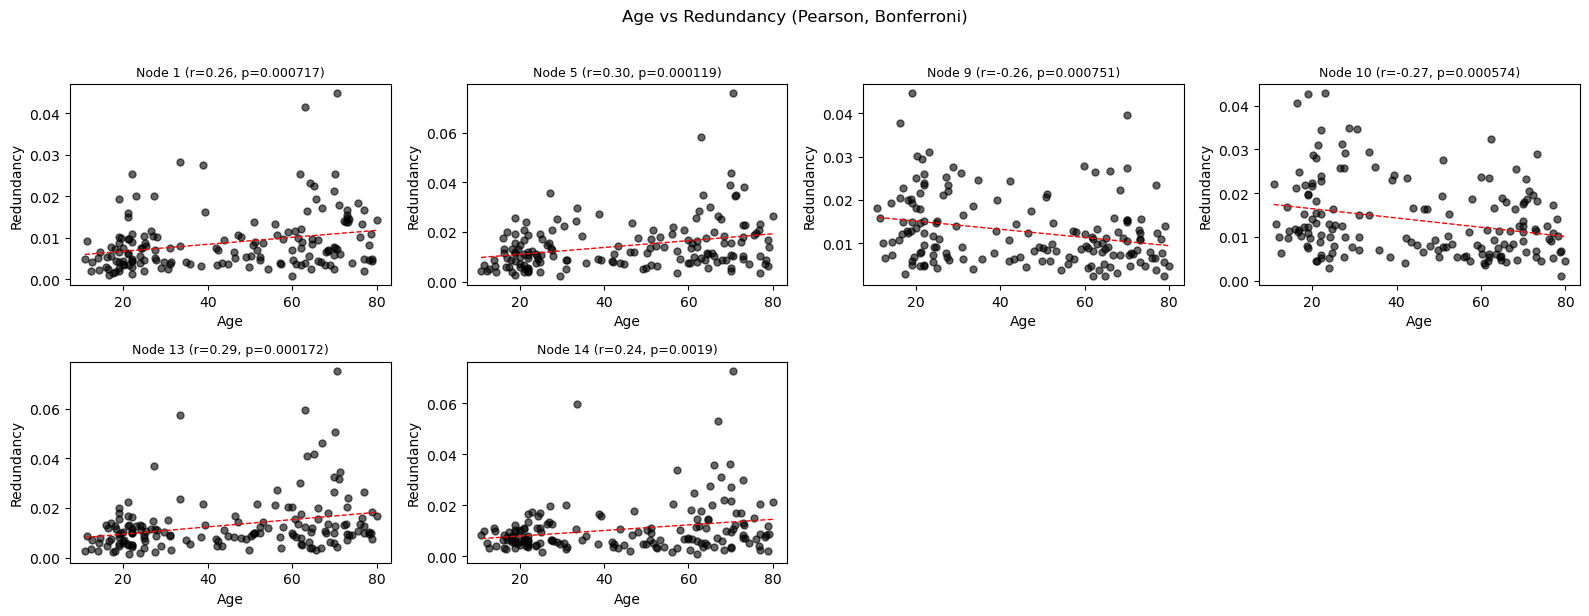

In [10]:

# Redundancy
plot_age_vs_metric(age_data, Red, "Redundancy", "Age vs Redundancy (Pearson, Bonferroni)")


Synergy: significant nodes (Bonferroni): [13 15 18 19]


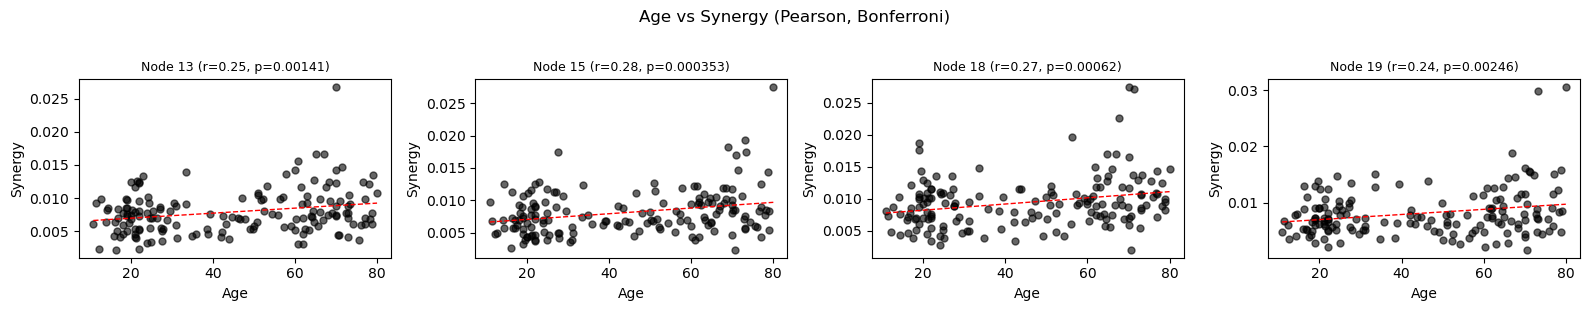

In [11]:

# Synergy
plot_age_vs_metric(age_data, Syn, "Synergy", "Age vs Synergy (Pearson, Bonferroni)")


**Note**. For simplicity, this tutorial examines linear age effects. Nonetheless, non-linear age-related changes across the lifespan have been widely observed, and analyses may benefit from explicitly modeling such effects.